# Read in the split data and load the YAML metadata

In [1]:
# Import the required modules

import pandas as pd
pd.set_option('display.float_format', lambda x: '%.3f' % x)

import numpy as np
import scipy as sp
import yaml
import matplotlib.pyplot as plt

from sklearn import linear_model
from sklearn.cluster import MiniBatchKMeans, KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.metrics.pairwise import pairwise_distances_argmin
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import (
    HalvingGridSearchCV,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split,
    KFold,
)
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, KFold
from sklearn.base import clone

from sklearn.metrics import silhouette_score, davies_bouldin_score



In [2]:
# Import the split data
X_train_path = 'bin/X_train.csv'
y_train_path = 'bin/y_train.csv'
X_test_path = 'bin/X_test.csv'
y_test_path = 'bin/y_test.csv'

X_train = pd.read_csv(X_train_path)
y_train = pd.read_csv(y_train_path)
X_test = pd.read_csv(X_test_path)
y_test = pd.read_csv(y_test_path)

# flatten target 
target_variable = 'Beta_winsorized'
y_train = y_train[target_variable].values.ravel()
y_test  = y_test[target_variable].values.ravel()

# print the shape of the data
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# print the first 5 rows of the data
print(X_train[:5])
print(y_train[:5])
print(X_test[:5])
print(y_test[:5])
	


(40433, 879)
(40433,)
(10109, 879)
(10109,)
    x74r   term    ltv   cltv    dti    pti  age_o1  age_o2  age_o3  \
0 -1.898  0.560  0.919  0.905  0.249  1.233   0.000   0.000   0.000   
1  1.294 -1.710  0.068  0.054 -0.628 -0.296   0.000   0.000   0.000   
2  0.230  0.560  0.268  0.255 -0.788 -1.730   0.000   0.000   0.000   
3  1.648  0.560 -1.235 -1.247  0.249  0.659   0.000   0.000   0.000   
4  1.010  0.560 -0.734 -0.746 -0.788 -1.156   0.000   0.000   0.000   

   score_orig_r  ...  close_month_5  close_month_6  close_month_7  \
0         0.144  ...          False          False          False   
1         1.056  ...          False          False          False   
2         0.576  ...          False          False          False   
3        -0.912  ...          False          False          False   
4         0.640  ...          False          False          False   

   close_month_8  close_month_9  close_month_10  close_month_11  \
0          False          False           False

In [3]:
# ---- metadata needed for feature-name lookups ----
import yaml

# variable labels (short human-readable descriptions)
with open('variable_labels.yaml') as f:
    variable_labels_dict = yaml.safe_load(f)

# SAS format for each original variable (tells you if cat / numeric)
with open('variable_formats.yaml') as f:
    variable_formats_dict = yaml.safe_load(f)

# mapping from format-name → {category-code: category-text}
with open('categorical_variables_categories.yaml') as f:
    categorical_variables_categories_dict = yaml.safe_load(f)

# list of all one-hot (dummy) columns produced during cleaning
with open('cleaned_variables.yaml') as f:
    cleaned_vars = yaml.safe_load(f)
new_categorical_variables = set(cleaned_vars['categorical_variables'])

In [4]:
# Set the target variable
target_variable = 'Beta_winsorized'

# print the value of the target variable from the training data to validate it loaded correctly
print(pd.Series(y_train, name=target_variable).head())

0   1.009
1   1.774
2   1.438
3   1.248
4   0.988
Name: Beta_winsorized, dtype: float64


# Supervised Learning Models: k-NN LASSO, Gradient Boosting,

### Helper Function

In [5]:
# def tune_and_evaluate(
#         model_cls, param_grid,
#         X_train, y_train, X_test, y_test,
#         metric='neg_root_mean_squared_error',
#         cv_splits=5, random_state=42,
#         label='', search_strategy='grid', n_iter=10, factor=3):

#     cv = KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

#     # ---- pipeline wrapper only for k-NN ---------------------------
#     if issubclass(model_cls, KNeighborsRegressor):
#         base = Pipeline([('scale', StandardScaler()),
#                          ('knn',   model_cls())])
#         param_grid = {('knn__' + k if not k.startswith('knn__') else k): v
#                       for k, v in param_grid.items()}
#     else:
#         base_kwargs = {}
#         if 'random_state' in model_cls().get_params():
#             base_kwargs['random_state'] = random_state
#         base = model_cls(**base_kwargs)

#     strategy = {
#         'grid':    (GridSearchCV,         {'param_grid': param_grid}),
#         'random':  (RandomizedSearchCV,   {'param_distributions': param_grid,
#                                            'n_iter': n_iter,
#                                            'random_state': random_state}),
#         'halving': (HalvingGridSearchCV,  {'param_grid': param_grid,
#                                            'factor': factor,
#                                            'random_state': random_state})
#     }[search_strategy]

#     search = strategy[0](estimator=base, scoring=metric, cv=cv,
#                          n_jobs=-1, verbose=1, **strategy[1]).fit(X_train, y_train)

#     best = search.best_estimator_
#     y_pred = best.predict(X_test)
#     mse  = mean_squared_error(y_test, y_pred)
#     rmse = np.sqrt(mse)
#     mae  = mean_absolute_error(y_test, y_pred)

#     return best, {'model': f'{label or model_cls.__name__} '
#                            f'(tuned – {search_strategy.capitalize()})',
#                   'MAE': mae, 'RMSE': rmse,
#                   'best_params': search.best_params_,
#                   'cv_best_score': search.best_score_}


### Hyper-parameter grids

In [6]:
gb_grid  = {'learning_rate': [0.02, 0.03, 0.05],
            'max_depth':     [None, 10, 18],
            'max_iter':      [300, 500],
            'l2_regularization': [0, .0005, .001],
            'min_samples_leaf': [10, 20],
            'max_leaf_nodes':   [31, 63]}

lasso_grid = {'alpha': np.logspace(-4, -1, 7), 'max_iter': [5000]}

knn_grid   = {'n_neighbors': [3,5,7,11,15],
              'weights':     ['uniform', 'distance'],
              'p':           [1,2]}            # 1 = Manhattan, 2 = Euclidean


### Train and tune the models

In [7]:
# results, best_models = [], {}
# for lab, cls, grid in [
#         ('GB',    HistGradientBoostingRegressor, gb_grid),
#         ('Lasso', Lasso,                         lasso_grid),
#         ('k-NN',  KNeighborsRegressor,           knn_grid)]:

#     best, res = tune_and_evaluate(cls, grid,
#                                   X_train, y_train,
#                                   X_test,  y_test,
#                                   label=lab,
#                                   search_strategy='halving' if lab=='GB' else 'grid')
#     best_models[lab], results = best, results + [res]
#     print(res)

# results_df = (pd.DataFrame(results)
#               .set_index('model')
#               .sort_values('RMSE'))
# display(results_df.style.format({'MAE':'{:.4f}','RMSE':'{:.4f}'}))


In [8]:
#  Gradient Boosting Regression (Cross-Validation)                0.3970                    0.584  {'learning_rate': 0.025, 'max_depth': 10, 'max... 

### Feature-importance & Ablation

In [9]:
# models = {
#     'k-NN' : best_models['k-NN'],
#     'GB'   : best_models['GB'],
#     'Lasso': best_models['Lasso']
# }


# perm_imps = {}
# for name, mdl in models.items():
#     fitted = clone(mdl).fit(X_train, y_train)
#     perm = permutation_importance(fitted, X_test, y_test,
#                                   n_repeats=10, random_state=42,
#                                   scoring='neg_root_mean_squared_error',
#                                   n_jobs=-1)
#     s = pd.Series(perm.importances_mean, index=X_train.columns)
#     perm_imps[name] = s.sort_values(ascending=False).head(15)


# # Needs further analysis
# groups = {
#     'Credit_Score': ['score_orig_r', 'score_orig_s'],
#     'LTV':          ['ltv', 'cltv'],
#     'DTI':          ['dti', 'pti']
# }

# def rmse_cv(mdl, X, y):
#     sc = cross_val_score(clone(mdl), X, y,
#                          scoring='neg_root_mean_squared_error',
#                          cv=KFold(5, shuffle=True, random_state=42),
#                          n_jobs=-1)
#     return -sc.mean()

# ablations = {}
# for name, mdl in models.items():
#     base = rmse_cv(mdl, X_train, y_train)
#     abl  = {g: rmse_cv(mdl, X_train.drop(columns=cols), y_train) - base
#             for g, cols in groups.items()}
#     ablations[name] = pd.Series(abl).sort_values()


# sns.set_style("whitegrid")
# fig, axes = plt.subplots(len(models), 2, figsize=(12, 4*len(models)),
#                          gridspec_kw={'wspace':0.35})

# palette = sns.color_palette("colorblind", len(models))

# for i, (name, imp) in enumerate(perm_imps.items()):
#     # (left) permutation importance
#     imp[::-1].plot.barh(ax=axes[i,0], color=palette[i])
#     axes[i,0].set_title(f'{name}: permutation importance')
#     axes[i,0].set_xlabel('Δ CV RMSE')

#     # (right) ablation
#     ablations[name][::-1].plot.barh(ax=axes[i,1], color=palette[i])
#     axes[i,1].set_title(f'{name}: group ablation ΔRMSE')
#     axes[i,1].set_xlabel('Δ RMSE (drop − full)')
#     axes[i,1].axvline(0, color='k', lw=0.8)

# fig.suptitle('Feature importance & group ablation across models', fontsize=16, y=1.02)
# plt.tight_layout()
# plt.show()

### Sensitivity Curves

In [10]:
       
# sns.set_style("whitegrid")

# # k-NN (n_neighbors 1–19, odd)
# k_vals, knn_rmse, knn_std = [], [], []
# for k in range(1, 21, 2):
#     mdl = Pipeline([('scale', StandardScaler()),
#                     ('knn',  KNeighborsRegressor(n_neighbors=k))])
#     sc = cross_val_score(mdl, X_train, y_train,
#                          scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
#     k_vals.append(k); knn_rmse.append(-sc.mean()); knn_std.append(sc.std())
# best_k = k_vals[int(np.argmin(knn_rmse))]

# # Gradient Boosting (learning_rate 10⁻³ … 1)
# rates = np.logspace(-3, 0, 7)
# gb_rmse, gb_std = [], []
# for lr in rates:
#     mdl = HistGradientBoostingRegressor(learning_rate=lr, max_iter=400, random_state=42)
#     sc  = cross_val_score(mdl, X_train, y_train,
#                           scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
#     gb_rmse.append(-sc.mean()); gb_std.append(sc.std())
# best_lr = rates[int(np.argmin(gb_rmse))]

# # Lasso (alpha 10⁻⁴ … 10¹)
# alphas = np.logspace(-4, 1, 8)
# las_rmse, las_std = [], []
# for a in alphas:
#     mdl = Pipeline([('scale', StandardScaler()),
#                     ('lasso', Lasso(alpha=a, random_state=42, max_iter=50_000))])
#     sc  = cross_val_score(mdl, X_train, y_train,
#                           scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
#     las_rmse.append(-sc.mean()); las_std.append(sc.std())
# best_a = alphas[int(np.argmin(las_rmse))]


### Learning Curves 

In [11]:
# best_knn = Pipeline([('scale', StandardScaler()),
#                      ('knn',  KNeighborsRegressor(n_neighbors=best_k))])

# best_gb  = HistGradientBoostingRegressor(learning_rate=best_lr, max_iter=400,
#                                          random_state=42)

# best_las = Pipeline([('scale', StandardScaler()),
#                      ('lasso', Lasso(alpha=best_a, random_state=42, max_iter=50_000))])

# def lc(model):
#     s, t, v = learning_curve(model, X_train, y_train,
#                               cv=5,
#                               scoring='neg_root_mean_squared_error',
#                               train_sizes=np.linspace(0.1, 1.0, 8),
#                               n_jobs=-1)
#     return s, -v.mean(axis=1), v.std(axis=1)

# sizes_knn, lc_knn, std_knn = lc(best_knn)
# sizes_gb , lc_gb , std_gb  = lc(best_gb)
# sizes_las, lc_las, std_las = lc(best_las)


### Plot Learning and Sensitivity Curves

In [12]:
# global_best = min(knn_rmse + gb_rmse + las_rmse)

# sns.set_style("whitegrid")

# palette = sns.color_palette("colorblind", 3)
# fig, axes = plt.subplots(3, 2, figsize=(11, 12), sharey=True)
# models_info = [
#     ('k-NN',  k_vals,     knn_rmse, knn_std, best_k,  palette[0],
#      sizes_knn, lc_knn, std_knn),
#     ('GB',    rates,      gb_rmse,  gb_std,  best_lr, palette[1],
#      sizes_gb, lc_gb,  std_gb),
#     ('Lasso', alphas,     las_rmse, las_std, best_a,  palette[2],
#      sizes_las, lc_las, std_las)
# ]

# for row, (name, x, rmse, err, best_x, color, s, lc_y, lc_std) in enumerate(models_info):
#     # Sensitivity curve (left column)
#     axes[row, 0].errorbar(x, rmse, yerr=err, marker='o', color=color)
#     axes[row, 0].scatter(best_x, min(rmse), s=90, c='red', zorder=3,
#                          label=f'best = {best_x:.3g}')
#     if name == 'GB':
#         axes[row, 0].set_xscale('log')
#     axes[row, 0].set_xlabel({'k-NN':'n_neighbors', 'GB':'learning_rate', 'Lasso':'alpha'}[name])
#     axes[row, 0].set_title(f'{name}: sensitivity'); axes[row, 0].legend()

#     # Learning curve (right column)
#     axes[row, 1].errorbar(s, lc_y, yerr=lc_std, marker='o', color=color)
#     axes[row, 1].set_xlabel('Training examples')
#     axes[row, 1].set_title(f'{name}: learning curve')

# # consistent y-axis + baseline
# all_vals = knn_rmse + gb_rmse + las_rmse + list(lc_knn) + list(lc_gb) + list(lc_las)
# ymin, ymax = min(all_vals)*0.97, max(all_vals)*1.03
# for ax in axes.ravel():
#     ax.set_ylim(ymin, ymax)
#     ax.axhline(global_best, ls='--', lw=1, color='grey', alpha=0.6)

# fig.text(0.04, 0.5, 'CV RMSE (lower = better)', va='center', rotation='vertical')
# fig.suptitle('Model Sensitivity & Learning Curves (k-NN, GB, Lasso)', fontsize=15, y=1.02)
# fig.tight_layout()
# plt.show()

### Failure analysis  (worst three rows)

In [13]:
# fitted = {
#     name: clone(mdl).fit(X_train, y_train)
#     for name, mdl in {
#         'k-NN':  best_knn,
#         'GB':    best_gb,
#         'Lasso': best_las
#     }.items()
# }

# errs = {}
# for name, mdl in fitted.items():
#     pred          = mdl.predict(X_test)
#     df            = pd.DataFrame({'true': y_test, 'pred': pred})
#     df['resid']   = df['true'] - df['pred']
#     df['abs_err'] = df['resid'].abs()
#     errs[name]    = df

# sns.set_style("whitegrid")
# fig, axes = plt.subplots(3, 2, figsize=(12, 12),
#                          gridspec_kw={'wspace':0.3, 'hspace':0.35})

# palette = sns.color_palette("colorblind", 3)

# for i, (name, df) in enumerate(errs.items()):
#     # (a) true vs pred scatter
#     sc = axes[i,0].scatter(df['true'], df['pred'],
#                            c=df['abs_err'], cmap='viridis_r', alpha=0.7)
#     axes[i,0].plot([df['true'].min(), df['true'].max()],
#                    [df['true'].min(), df['true'].max()],
#                    ls='--', color='grey')
#     axes[i,0].set_xlabel('Actual'); axes[i,0].set_ylabel('Predicted')
#     axes[i,0].set_title(f'{name}: true vs. pred')
#     fig.colorbar(sc, ax=axes[i,0], label='|error|')

#     # (b) residual histogram
#     sns.histplot(df['resid'], bins=30, kde=True,
#                  ax=axes[i,1], color=palette[i])
#     axes[i,1].axvline(0, color='k', lw=0.8)
#     axes[i,1].set_xlabel('Residual (true − pred)')
#     axes[i,1].set_title(f'{name}: residual distribution')

# fig.suptitle('Failure analysis across models', fontsize=16, y=1.02)
# plt.tight_layout()
# plt.show()


# for name, df in errs.items():
#     display(pd.DataFrame({name: '─'}, index=[0]))   # visual separator
#     display(df.nlargest(10, 'abs_err').style.set_caption(f'Worst 10 – {name}'))

In [14]:

# n_bins = 5
# bin_edges = np.quantile(y_train, np.linspace(0, 1, n_bins + 1))
# bin_labels = [f'Q{i+1}' for i in range(n_bins)]  # Q1 … Q5

# def bin_series(s):
#     """Digitise a numeric Series to quintile labels using fixed edges."""
#     idx = np.digitize(s, bin_edges[1:-1], right=False)   # 0 … 4
#     return pd.Categorical.from_codes(idx, categories=bin_labels, ordered=True)

# models = {
#     'k-NN' : best_knn,
#     'GB'   : best_gb,
#     'Lasso': best_las
# }

# true_bins = bin_series(y_test)

# cmaps = sns.color_palette("light:b", as_cmap=True)
# fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

# max_val = 0  # track global max for common colour scale
# cms = {}

# for ax, (name, mdl) in zip(axes, models.items()):
#     pred_bins = bin_series(mdl.predict(X_test))
#     cm = confusion_matrix(true_bins, pred_bins, labels=bin_labels)
#     cms[name] = cm
#     max_val = max(max_val, cm.max())


# for ax, (name, cm) in zip(axes, cms.items()):
#     sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
#                 vmin=0, vmax=max_val, cbar=False,
#                 xticklabels=bin_labels, yticklabels=bin_labels,
#                 ax=ax)
#     ax.set_xlabel('Predicted quintile'); ax.set_ylabel('True quintile')
#     ax.set_title(f'{name}')

# # single colour bar
# fig.colorbar(axes[0].collections[0], ax=axes, location='right',
#              label='Count', fraction=0.04)

# fig.suptitle('Quintile confusion matrices (lower-↙ / higher-↗)', y=1.05, fontsize=15)
# plt.tight_layout()
# plt.show()

### Use the models to identify the most useful variable to predict the target

In [15]:
# # === Linear Regression: largest absolute coefficients ================

# TOP_N = 20
# lin_coef = pd.Series(linreg.coef_, index=X_train.columns)
# lin_top = lin_coef.abs().sort_values(ascending=False).head(TOP_N)

# print(f"Top {TOP_N} Linear-Regression coefficients")
# for var, coef in lin_top.items():
#     sign = "+" if coef > 0 else "-"
#     if var in new_categorical_variables:
#         parts = var.split("_")
#         cat_var, category = "_".join(parts[:-1]), parts[-1]
#         category = int(category) if category.isdigit() else category
#         label = categorical_variables_categories_dict[variable_formats_dict[cat_var]][category]
#         print(f"{var} | {variable_labels_dict[cat_var]} = {label} | coef {sign}{abs(coef):.4f}")
#     else:
#         print(f"{var} | {variable_labels_dict[var]} | coef {sign}{abs(coef):.4f}")

In [16]:
# # === Lasso: non-zero coefficients (already sparse) ====================

# lasso_coef = pd.Series(best_lasso.coef_, index=X_train.columns)
# nz = lasso_coef[lasso_coef != 0].sort_values(key=np.abs, ascending=False)

# print(f"{len(nz)} non-zero Lasso coefficients")
# for var, coef in nz.items():
#     sign = "+" if coef > 0 else "-"
#     if var in new_categorical_variables:
#         parts = var.split("_")
#         cat_var, category = "_".join(parts[:-1]), parts[-1]
#         category = int(category) if category.isdigit() else category
#         label = categorical_variables_categories_dict[variable_formats_dict[cat_var]][category]
#         print(f"{var} | {variable_labels_dict[cat_var]} = {label} | coef {sign}{abs(coef):.4f}")
#     else:
#         print(f"{var} | {variable_labels_dict[var]} | coef {sign}{abs(coef):.4f}")

In [17]:
# # === Random Forest: top N features by importance ======================

# TOP_N = 20
# rf_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
# rf_top = rf_importances.sort_values(ascending=False).head(TOP_N)

# print(f"Top {TOP_N} Random-Forest features")
# for var, imp in rf_top.items():
#     if var in new_categorical_variables:
#         parts = var.split("_")
#         cat_var, category = "_".join(parts[:-1]), parts[-1]
#         category = int(category) if category.isdigit() else category
#         label = categorical_variables_categories_dict[variable_formats_dict[cat_var]][category]
#         print(f"{var} | {variable_labels_dict[cat_var]} = {label} | importance {imp:.4f}")
#     else:
#         print(f"{var} | {variable_labels_dict[var]} | importance {imp:.4f}")

In [18]:
# # --- Compare all supervised models -----------------------------------
# import pandas as pd

# all_metrics = [gb_metrics, linreg_metrics, lasso_metrics, rf_metrics]

# results_df = (pd.DataFrame(all_metrics)
#                 .set_index('model')
#                 .sort_values('RMSE'))   # sort best → worst by RMSE

# display(results_df.style.format({'MAE': '{:.4f}', 'RMSE': '{:.4f}'}))

In [19]:
# results_df[['RMSE']].plot(kind='barh', figsize=(6,3), legend=False,
#                           title='Test RMSE by Model').invert_yaxis()
# plt.xlabel('RMSE')
# plt.show()

## Unsupervised Learning

In [20]:
# Decide the source matrix for clustering
X_cluster = pd.concat([X_train, X_test], ignore_index=True)

# Keeps only numeric columns
num_cols = X_cluster.select_dtypes(include=[np.number]).columns
X_cluster_numeric = X_cluster[num_cols]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster_numeric)

print(f"Original shape: {X_cluster_numeric.shape},  scaled shape: {X_scaled.shape}")

Original shape: (50542, 14),  scaled shape: (50542, 14)


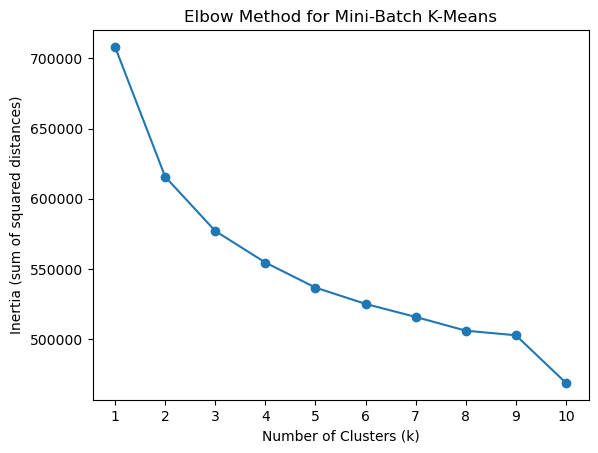

In [21]:
# --- Mini-Batch K-means elbow plot -----------------------------------
inertias = []

for k in range(1, 11):
    mbk = MiniBatchKMeans(
        n_clusters=k,
        init='k-means++',
        batch_size=100,
        n_init=10,
        max_no_improvement=10,
        random_state=0,
        verbose=0
    )
    mbk.fit(X_scaled)               
    inertias.append(mbk.inertia_)

plt.plot(range(1, 11), inertias, marker='o')
plt.xticks(range(1, 11))
plt.xlabel('Number of Clusters (k)')
plt.ylabel("Inertia (sum of squared distances)")
plt.title('Elbow Method for Mini-Batch K-Means')
plt.show()

In [22]:
def eval_kmeans(X, ks=(3,4,5,6)):
    out = []
    for k in ks:
        km = MiniBatchKMeans(n_clusters=k, random_state=0, n_init=10,
                             batch_size=100).fit(X)
        out.append((k,
                    silhouette_score(X, km.labels_),
                    davies_bouldin_score(X, km.labels_)))
    return pd.DataFrame(out, columns=['k','silhouette','davies'])

# 1) Same features, try k 3–6
print("Raw scaled")
print(eval_kmeans(X_scaled))

# 2) PCA space, keep 95 % variance
pca    = PCA(n_components=0.95, random_state=0)
X_pca  = pca.fit_transform(X_scaled)
print("\nPCA space")
print(eval_kmeans(X_pca))

Raw scaled
   k  silhouette  davies
0  3       0.155   2.005
1  4       0.150   1.987
2  5       0.148   1.889
3  6       0.120   1.957

PCA space
   k  silhouette  davies
0  3       0.155   2.001
1  4       0.148   2.054
2  5       0.149   1.886
3  6       0.122   1.949


In [23]:
# Choose the matrix for clustering
X_kmeans = X_scaled          

k = 5                 
mbk = MiniBatchKMeans(init='k-means++',
                      n_clusters=k,
                      batch_size=100,
                      n_init=10,
                      max_no_improvement=10,
                      random_state=0,
                      verbose=0)

mbk.fit(X_kmeans)

cluster_centers = np.sort(mbk.cluster_centers_, axis=0)
labels = pairwise_distances_argmin(X_kmeans, cluster_centers)

print(labels)                # cluster assignment per observation

[3 3 1 ... 4 2 2]


Starting PCA…
Number of PCs selected: 12


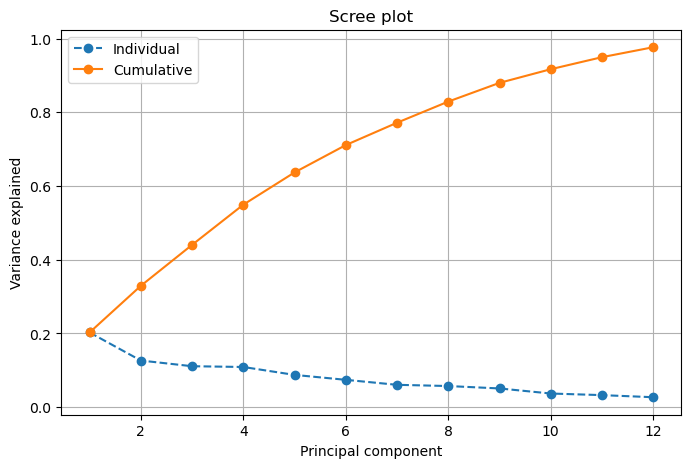

Shape after PCA: (50542, 12)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,1.863,0.118,-0.024,-0.376,1.034,0.089,-1.308,-0.133,0.760,0.012,0.242,-0.372
1,-1.766,-0.082,-0.170,-0.301,0.969,-0.118,-0.026,0.218,-2.018,-0.054,-0.183,-0.241
2,-0.401,0.231,-0.397,-1.605,-0.286,-0.078,0.948,0.109,-0.109,0.057,0.264,0.653
3,-0.981,-0.296,0.371,1.746,-0.544,0.013,1.346,0.029,0.574,-0.077,-0.585,-0.647
4,-1.512,0.035,-0.176,-0.561,-0.383,-0.060,1.324,0.082,0.298,0.088,0.341,0.195


In [24]:
# --- PCA --------------------------------------------------------------
print("Starting PCA…")

X_pca = pca.transform(X_scaled)

print(f"Number of PCs selected: {pca.n_components_}")

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, pca.n_components_+1), pca.explained_variance_ratio_, 'o--', label='Individual')
plt.plot(range(1, pca.n_components_+1), cum_var, 'o-', label='Cumulative')
plt.xlabel('Principal component'); plt.ylabel('Variance explained')
plt.title('Scree plot'); plt.grid(True); plt.legend(); plt.show()

print("Shape after PCA:", X_pca.shape)
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
display(X_pca_df.head())

In [25]:
X_gmm = X_scaled     

# Initial fit with k=4, covariance 'full'
gmm = GaussianMixture(n_components=4,
                      covariance_type='full',
                      random_state=0).fit(X_gmm)

gmm_labels = gmm.predict(X_gmm)
print("First 10 GMM labels:", gmm_labels[:10])
print("Unique clusters:", np.unique(gmm_labels))

First 10 GMM labels: [1 1 1 1 1 1 1 1 1 1]
Unique clusters: [0 1 2 3]


Best k by BIC = 18


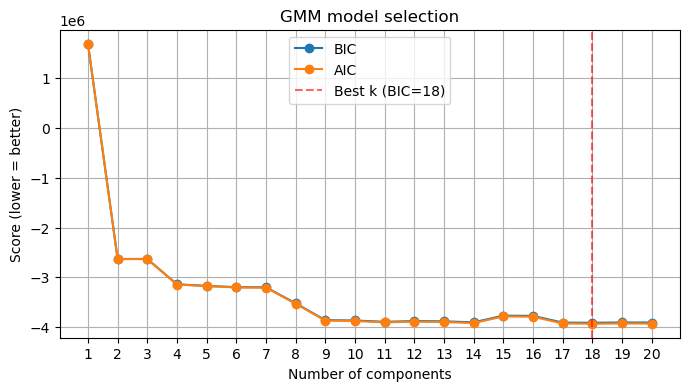

In [26]:
# --- compute BIC / AIC ------------------------------------------------
n_components_range = range(1, 21)
bics, aics = [], []

bics = [GaussianMixture(k, covariance_type='full',
                        random_state=0).fit(X_gmm).bic(X_gmm)
        for k in n_components_range]

best_k = n_components_range[np.argmin(bics)]
print("Best k by BIC =", best_k)

for k in n_components_range:
    gm = GaussianMixture(n_components=k, covariance_type='full',
                         random_state=0).fit(X_gmm)
    aics.append(gm.aic(X_gmm))

# --- diagnostic plot --------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(n_components_range, bics, 'o-', label='BIC')
plt.plot(n_components_range, aics, 'o-', label='AIC')

best_k = n_components_range[np.argmin(bics)]
plt.axvline(best_k, color='red', ls='--', alpha=0.6,
            label=f'Best k (BIC={best_k})')

plt.xlabel('Number of components'); plt.ylabel('Score (lower = better)')
plt.title('GMM model selection'); plt.xticks(n_components_range)
plt.legend(); plt.grid(True); plt.show()

In [27]:
sil = silhouette_score(X_gmm, gmm_labels)
db  = davies_bouldin_score(X_gmm, gmm_labels)
print(f"Silhouette: {sil:.3f}   Davies-Bouldin: {db:.3f}")

Silhouette: 0.434   Davies-Bouldin: 10.754


In [28]:
final_k = 10

gmm = GaussianMixture(n_components=final_k,
                      covariance_type='full',
                      random_state=0).fit(X_gmm)
gmm_labels = gmm.predict(X_gmm)

sil   = silhouette_score(X_gmm, gmm_labels)
print(f"GMM k={final_k}   Silhouette = {sil:.3f}")

GMM k=10   Silhouette = 0.038


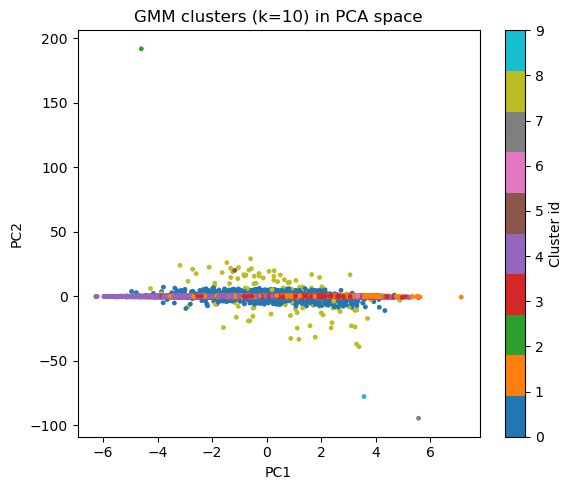

In [29]:
k_gmm = final_k      

pc1, pc2 = X_pca[:,0], X_pca[:,1]

fig, ax = plt.subplots(figsize=(6,5))
sc = ax.scatter(pc1, pc2, c=gmm_labels, cmap='tab10', s=6)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'GMM clusters (k={k_gmm}) in PCA space')
plt.colorbar(sc, label='Cluster id')
plt.tight_layout(); plt.show()

Starting DBSCAN...
Calculating k-distances for eps estimation (min_samples = 10)...


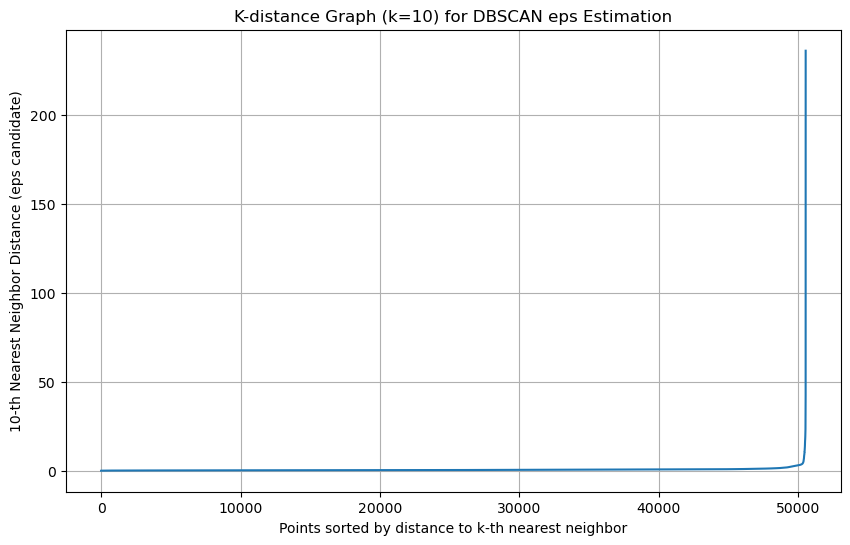

Review the K-distance plot above to choose a suitable 'eps' value (y-axis value at the 'elbow').

Running DBSCAN with eps=0.5 and min_samples=10...

Estimated number of clusters: 59
Estimated number of noise points: 30805


In [30]:
print("Starting DBSCAN...")


min_samples_dbscan = 10 # Tune this parameter

print(f"Calculating k-distances for eps estimation (min_samples = {min_samples_dbscan})...")

neigh = NearestNeighbors(n_neighbors=min_samples_dbscan)
nbrs = neigh.fit(X_scaled) # or X_pca
distances, indices = nbrs.kneighbors(X_scaled) # or X_pca

# Sort the distances to the k-th nearest neighbor
k_distances = np.sort(distances[:, min_samples_dbscan-1], axis=0)

# Plot the k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title(f'K-distance Graph (k={min_samples_dbscan}) for DBSCAN eps Estimation')
plt.xlabel('Points sorted by distance to k-th nearest neighbor')
plt.ylabel(f'{min_samples_dbscan}-th Nearest Neighbor Distance (eps candidate)')
plt.grid(True)
# Look for the "elbow" or "knee" in this plot to choose eps.
# This point indicates a region where distances start to increase sharply.
plt.show()
print("Review the K-distance plot above to choose a suitable 'eps' value (y-axis value at the 'elbow').")


# --- DBSCAN Clustering ---
# You need to set 'eps' based on the k-distance plot.
# Let's pick an example value for eps; YOU MUST TUNE THIS.
eps_dbscan = 0.5 # Example value, TUNE THIS CAREFULLY based on the plot above.

print(f"\nRunning DBSCAN with eps={eps_dbscan} and min_samples={min_samples_dbscan}...")
dbscan = DBSCAN(eps=eps_dbscan, min_samples=min_samples_dbscan)

# Fit DBSCAN
# If using PCA-transformed data: dbscan.fit(X_pca)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Number of clusters in labels, ignoring noise if present.
# Noise points are labeled as -1.
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print(f"\nEstimated number of clusters: {n_clusters_dbscan}")
print(f"Estimated number of noise points: {n_noise_dbscan}")
# print(f"Cluster labels: {np.unique(dbscan_labels)}") # Shows all unique labels including -1 for noise

# --- End of DBSCAN ---

## Business Question

**Can we predict the systematic risk (Beta) of mortgages in the FHFA NSMO portfolio using mortgage characteristics and macroeconomic factors?**

### Supervised Learning Questions

- **Which mortgage features (loan characteristics, borrower profiles, property details) are most predictive of mortgage Beta?**
- **How accurately can different ML models predict mortgage Beta?**
- **Which model family (probabilistic, tree-based, instance-based) performs best for this financial prediction task?**

### Unsupervised Learning Questions

- **Are there natural groupings/clusters of mortgages based on their characteristics?**
- **Do these clusters correspond to different risk profiles (Beta levels)?**
- **Can we identify mortgage segments that behave similarly in terms of systematic risk?**

### Financial/Business Questions

- **How do mortgage characteristics influence systematic risk relative to market movements?**
- **Can we identify high-Beta vs low-Beta mortgage profiles for portfolio management?**